# YUVAA Internship — Week 2
## Data Visualization and Insight Generation

**Prepared by:** Avirup Karmakar

### Objective
Use the cleaned Week 1 crop-production data to create meaningful visualizations and generate insights about trends, seasonal variation, regional performance, relationships, and unusual changes.

**Dataset used:** `crop_production(1).csv`

**Dataset columns:** `index`, `State_Name`, `District_Name`, `Crop_Year`, `Season`, `Crop`, `Area`, `Production`

> Week 2 is focused on visualization and insight generation. The analysis below uses the cleaned dataset and does not invent data values.


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

print("Libraries imported successfully!")


Libraries imported successfully!


## 2. Load the Updated Dataset

In [2]:
df = pd.read_csv("crop_production.csv")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
display(df.head())


Dataset loaded successfully!
Rows: 246091
Columns: 8


,index,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production
0,0,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,1254.0,2000.0
1,1,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif pulses,2.0,1.0
2,2,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Rice,102.0,321.0
3,3,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Banana,176.0,641.0
4,4,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Cashewnut,720.0,165.0


## 3. Validate the Dataset

In [3]:
print("Column names:")
print(df.columns.tolist())

print("\nMissing values:")
display(df.isnull().sum().to_frame("Missing Values"))

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nData types:")
display(df.dtypes.to_frame("Data Type"))


Column names:
['index', 'State_Name', 'District_Name', 'Crop_Year', 'Season', 'Crop', 'Area', 'Production']

Missing values:


,Missing Values
index,0
State_Name,0
District_Name,0
Crop_Year,0
Season,0
Crop,0
Area,0
Production,3730



Duplicate rows:
0

Data types:


,Data Type
index,int64
State_Name,object
District_Name,object
Crop_Year,int64
Season,object
Crop,object
Area,float64
Production,float64


## 4. Prepare Data for Visualization

In [4]:
# Convert required analysis fields to numeric safely
df["Crop_Year"] = pd.to_numeric(df["Crop_Year"], errors="coerce")
df["Area"] = pd.to_numeric(df["Area"], errors="coerce")
df["Production"] = pd.to_numeric(df["Production"], errors="coerce")

# Keep only records required for the relevant visual analyses
analysis_df = df.dropna(
    subset=[
        "Crop_Year", "Area", "Production",
        "State_Name", "District_Name", "Season", "Crop"
    ]
).copy()

# Exclude impossible negative values
analysis_df = analysis_df[
    (analysis_df["Area"] >= 0) &
    (analysis_df["Production"] >= 0)
].copy()

print("Rows available for Week 2 analysis:", len(analysis_df))


Rows available for Week 2 analysis: 242361


## 5. Visualization Strategy

| Visualization | Type | Purpose |
|---|---|---|
| Annual production trend | Line graph | Identify changes and fluctuations over time |
| Top 10 crops | Horizontal bar chart | Compare crop-level production concentration |
| Top 10 states | Horizontal bar chart | Compare regional production |
| Seasonal production | Bar chart | Identify seasonal patterns |
| Area vs Production | Scatter plot | Examine the relationship between cultivated area and output |
| Top 10 districts | Horizontal bar chart | Identify high-performing local clusters |
| Year-over-year growth | Bar chart | Screen for unusually large annual changes |

Seven visualizations are included so the report exceeds the minimum requirement of three distinct graphical representations.


## 6. Annual Production Trend

In [5]:
yearly_production = (
    analysis_df.groupby("Crop_Year")["Production"]
    .sum()
    .sort_index()
)

display(yearly_production.to_frame("Total Production"))


,Total Production
Crop_Year,
1997,8.512329e+08
1998,5.825321e+09
1999,6.434666e+09
2000,7.449709e+09
2001,7.465541e+09
2002,7.696955e+09
2003,7.917974e+09
2004,8.189462e+09
2005,8.043757e+09


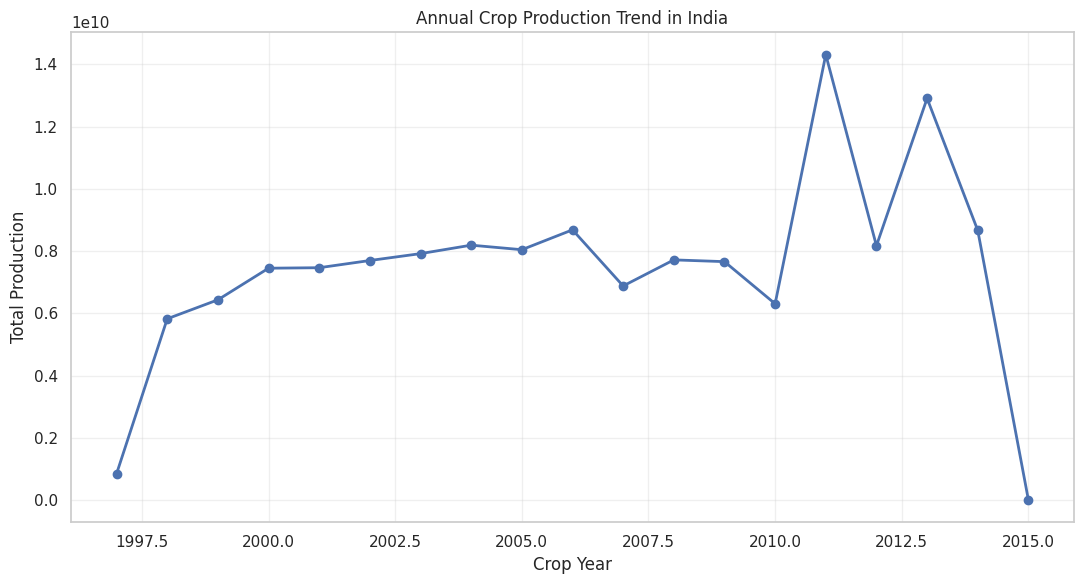

In [6]:
plt.figure(figsize=(11, 6))
plt.plot(
    yearly_production.index,
    yearly_production.values,
    marker="o",
    linewidth=2
)
plt.title("Annual Crop Production Trend in India")
plt.xlabel("Crop Year")
plt.ylabel("Total Production")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("01_annual_production_trend.png", dpi=300, bbox_inches="tight")
plt.show()


### Insight
Use this figure to describe whether production is generally increasing, decreasing, or fluctuating. Highlight years with notable movements and connect the observation to potential agribusiness planning implications.


## 7. Top 10 Crops by Total Production

In [7]:
crop_production = (
    analysis_df.groupby("Crop")["Production"]
    .sum()
    .sort_values(ascending=False)
)

display(crop_production.head(10).to_frame("Total Production"))


,Total Production
Crop,
Coconut,1.299816e+11
Sugarcane,5.535682e+09
Rice,1.605470e+09
Wheat,1.332826e+09
Potato,4.248263e+08
Cotton(lint),2.970000e+08
Maize,2.733418e+08
Jute,1.815582e+08
Banana,1.461327e+08


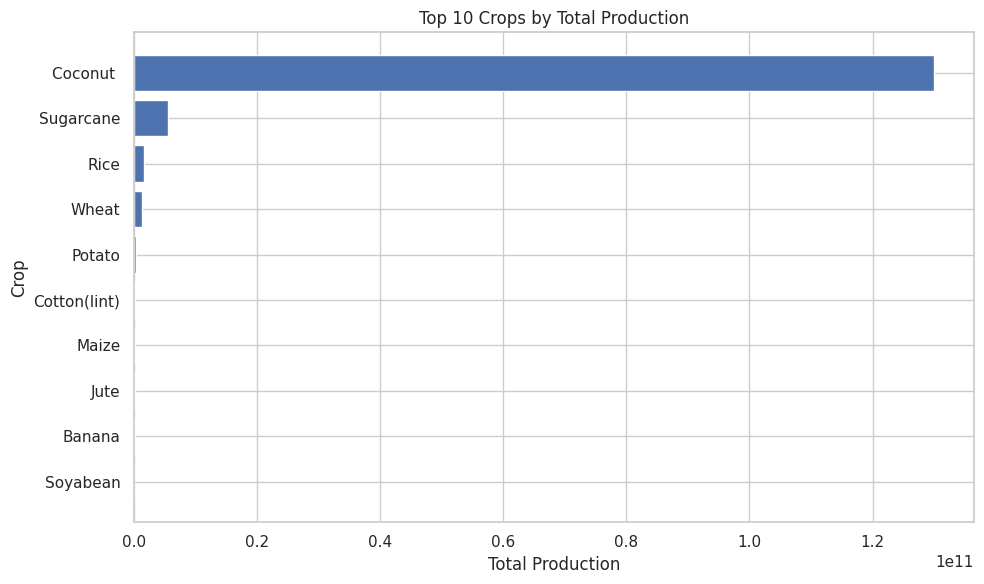

In [8]:
top10_crops = crop_production.head(10).sort_values()

plt.figure(figsize=(10, 6))
plt.barh(top10_crops.index, top10_crops.values)
plt.title("Top 10 Crops by Total Production")
plt.xlabel("Total Production")
plt.ylabel("Crop")
plt.tight_layout()
plt.savefig("02_top_10_crops.png", dpi=300, bbox_inches="tight")
plt.show()


### Insight
The crop comparison identifies the largest production categories. High-volume crops can have greater importance for procurement, storage, transport, processing and supply-chain planning.


## 8. Top 10 States by Total Production

In [9]:
state_production = (
    analysis_df.groupby("State_Name")["Production"]
    .sum()
    .sort_values(ascending=False)
)

display(state_production.head(10).to_frame("Total Production"))


,Total Production
State_Name,
Kerala,9.788005e+10
Andhra Pradesh,1.732459e+10
Tamil Nadu,1.207644e+10
Uttar Pradesh,3.234493e+09
Assam,2.111752e+09
West Bengal,1.397904e+09
Maharashtra,1.263641e+09
Karnataka,8.634298e+08
Andaman and Nicobar Islands,7.182232e+08


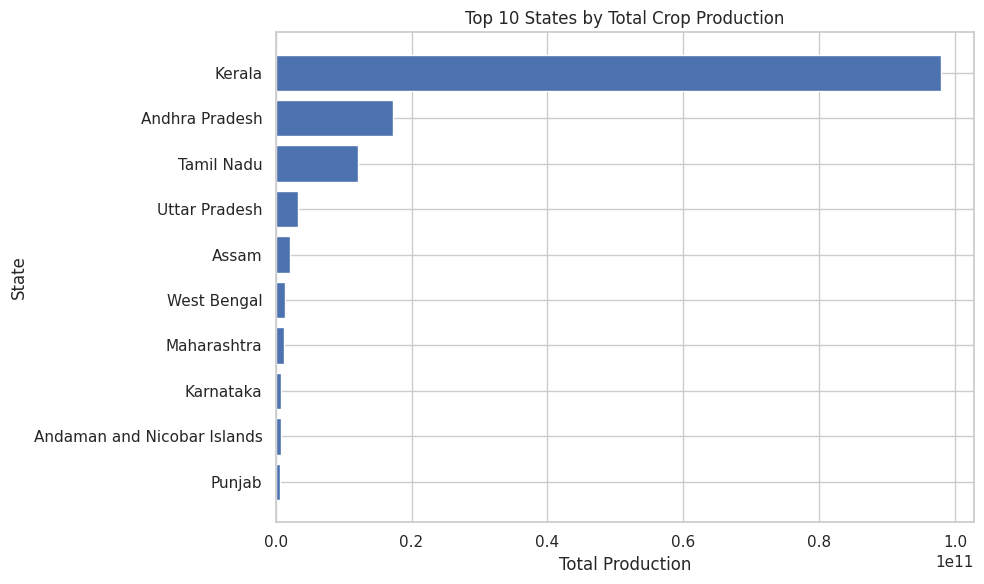

In [10]:
top10_states = state_production.head(10).sort_values()

plt.figure(figsize=(10, 6))
plt.barh(top10_states.index, top10_states.values)
plt.title("Top 10 States by Total Crop Production")
plt.xlabel("Total Production")
plt.ylabel("State")
plt.tight_layout()
plt.savefig("03_top_10_states.png", dpi=300, bbox_inches="tight")
plt.show()


### Insight
State-level differences reveal regional production concentration. Leading states can represent important sourcing and logistics clusters, while differences in output can guide further investigation into productivity and infrastructure.


## 9. Production by Agricultural Season

In [11]:
season_production = (
    analysis_df.groupby("Season")["Production"]
    .sum()
    .sort_values(ascending=False)
)

display(season_production.to_frame("Total Production"))


,Total Production
Season,
Whole Year,1.344248e+11
Kharif,4.029970e+09
Rabi,2.051688e+09
Winter,4.345498e+08
Summer,1.706579e+08
Autumn,6.441377e+07


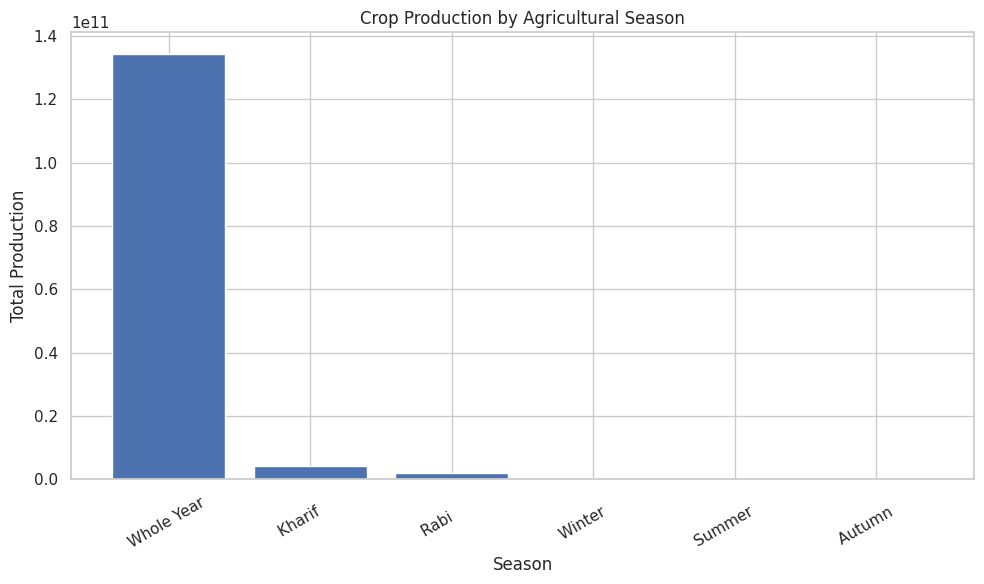

In [12]:
plt.figure(figsize=(10, 6))
plt.bar(season_production.index, season_production.values)
plt.title("Crop Production by Agricultural Season")
plt.xlabel("Season")
plt.ylabel("Total Production")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("04_seasonal_production.png", dpi=300, bbox_inches="tight")
plt.show()


### Insight
Seasonal variation is useful for planning procurement timing, storage, transportation and market-supply operations. Use the actual totals to identify the dominant season.


## 10. Cultivated Area vs Production

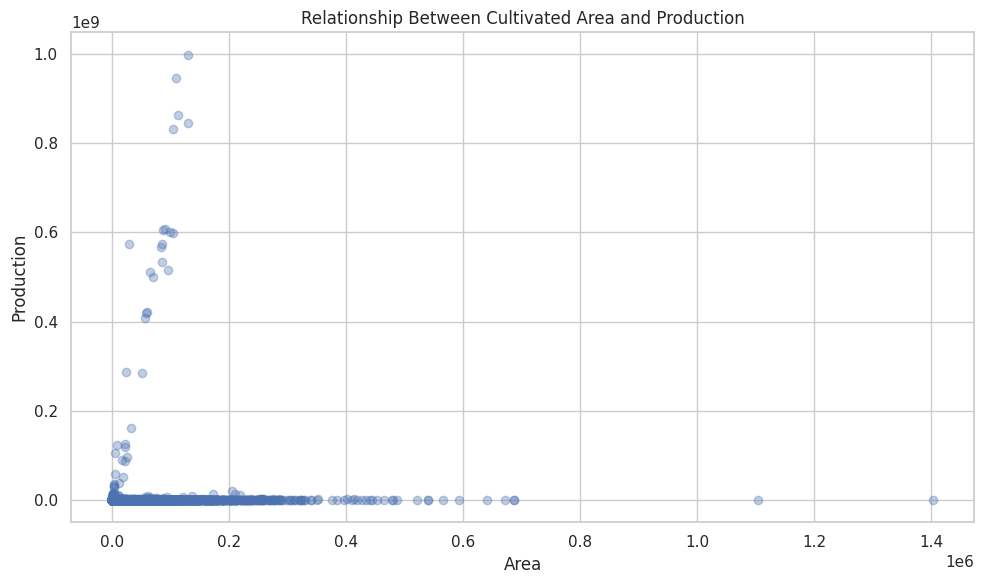

In [13]:
sample_df = analysis_df.sample(
    n=min(15000, len(analysis_df)),
    random_state=42
)

plt.figure(figsize=(10, 6))
plt.scatter(
    sample_df["Area"],
    sample_df["Production"],
    alpha=0.35
)
plt.title("Relationship Between Cultivated Area and Production")
plt.xlabel("Area")
plt.ylabel("Production")
plt.tight_layout()
plt.savefig("05_area_vs_production.png", dpi=300, bbox_inches="tight")
plt.show()


In [14]:
area_production_corr = analysis_df["Area"].corr(
    analysis_df["Production"]
)
print(f"Area–Production correlation: {area_production_corr:.3f}")


Area–Production correlation: 0.041


### Insight
The scatter plot shows the distribution of area and production observations. The correlation coefficient summarizes their linear association. It should be interpreted as a relationship in the data, not as proof that changes in area cause changes in production.


## 11. Top 10 Districts by Total Production

In [15]:
district_production = (
    analysis_df.groupby(
        ["State_Name", "District_Name"]
    )["Production"]
    .sum()
    .sort_values(ascending=False)
)

display(district_production.head(10).to_frame("Total Production"))


Total Production
State_Name     District_Name                       
Kerala         KOZHIKODE               1.528074e+10
               MALAPPURAM              1.451840e+10
               THIRUVANANTHAPURAM      1.002271e+10
               THRISSUR                9.923508e+09
               KANNUR                  9.783432e+09
Andhra Pradesh EAST GODAVARI           8.271057e+09
Kerala         KASARAGOD               7.732217e+09
               KOLLAM                  7.151945e+09
               PALAKKAD                6.369382e+09
               ERNAKULAM               5.021649e+09

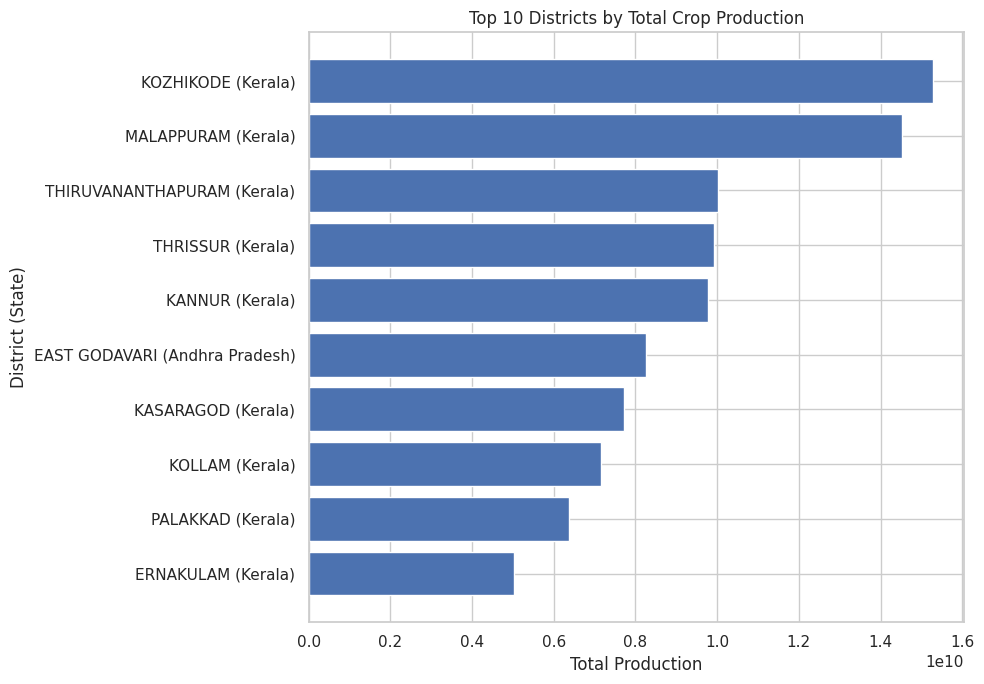

In [16]:
top10_districts = district_production.head(10).sort_values()

labels = [
    f"{district} ({state})"
    for state, district in top10_districts.index
]

plt.figure(figsize=(10, 7))
plt.barh(labels, top10_districts.values)
plt.title("Top 10 Districts by Total Crop Production")
plt.xlabel("Total Production")
plt.ylabel("District (State)")
plt.tight_layout()
plt.savefig("06_top_10_districts.png", dpi=300, bbox_inches="tight")
plt.show()


### Insight
District-level analysis helps identify localized production clusters. Such clusters can be relevant for aggregation, cold/storage infrastructure, processing and distribution planning.


## 12. Year-over-Year Growth and Anomaly Screening

In [17]:
yearly_growth = yearly_production.pct_change() * 100

growth_df = pd.DataFrame({
    "Year": yearly_growth.index,
    "YoY_Growth_%": yearly_growth.values
})

display(growth_df)


,Year,YoY_Growth_%
0,1997,NaN
1,1998,584.339221
2,1999,10.460288
3,2000,15.774605
4,2001,0.212515
5,2002,3.099766
6,2003,2.871504
7,2004,3.428759
8,2005,-1.779169
9,2006,7.933554


In [18]:
valid_growth = growth_df.dropna(subset=["YoY_Growth_%"]).copy()

print("Largest year-over-year increase:")
display(valid_growth.loc[valid_growth["YoY_Growth_%"].idxmax()])

print("\nLargest year-over-year decline:")
display(valid_growth.loc[valid_growth["YoY_Growth_%"].idxmin()])


Largest year-over-year increase:


,1
Year,1998.000000
YoY_Growth_%,584.339221



Largest year-over-year decline:


,18
Year,2015.00000
YoY_Growth_%,-99.91996


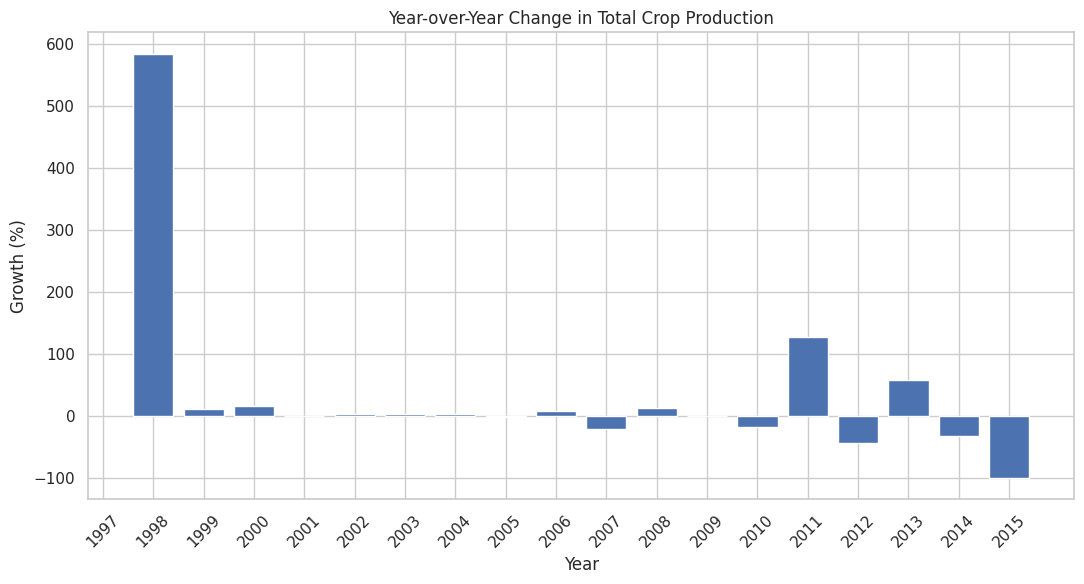

In [19]:
plt.figure(figsize=(11, 6))
plt.bar(
    growth_df["Year"].astype(int).astype(str),
    growth_df["YoY_Growth_%"]
)
plt.title("Year-over-Year Change in Total Crop Production")
plt.xlabel("Year")
plt.ylabel("Growth (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("07_yoy_growth.png", dpi=300, bbox_inches="tight")
plt.show()


### Anomaly / unusual-change insight
Large positive or negative year-over-year changes are treated as screening signals. They may reflect real changes in production conditions, cultivated area, crop mix, or reporting patterns and should be investigated rather than automatically deleted.


## 13. Agribusiness Insight Generation

In [20]:
print("DATA-DRIVEN SUMMARY")
print("-" * 60)
print("Top crop:", crop_production.index[0])
print("Top state:", state_production.index[0])
print("Top season:", season_production.index[0])
print("Highest production year:", int(yearly_production.idxmax()))
print("Area–Production correlation:", round(area_production_corr, 3))

if not valid_growth.empty:
    max_row = valid_growth.loc[valid_growth["YoY_Growth_%"].idxmax()]
    min_row = valid_growth.loc[valid_growth["YoY_Growth_%"].idxmin()]
    print(f"Largest YoY increase: {int(max_row['Year'])} ({max_row['YoY_Growth_%']:.2f}%)")
    print(f"Largest YoY decline: {int(min_row['Year'])} ({min_row['YoY_Growth_%']:.2f}%)")


DATA-DRIVEN SUMMARY
------------------------------------------------------------
Top crop: Coconut 
Top state: Kerala
Top season: Whole Year 
Highest production year: 2011
Area–Production correlation: 0.041
Largest YoY increase: 1998 (584.34%)
Largest YoY decline: 2015 (-99.92%)


## 14. Week 2 Reporting Guidance

For the DOC/DOCX report, explain each figure in terms of:
- what variables it represents,
- why the chart type was selected,
- what pattern is visible,
- what conclusion can be drawn,
- and what the observation could mean for agribusiness.

Include an Introduction, Methodology, Visualization Strategy, Tools/Software with justification, Analysis, Key Insights, Trends, Correlations, Anomalies, Agribusiness Opportunities, and Conclusion.

The final report must exceed 200 words and remain self-contained.


## 15. Conclusion

Week 2 converts the cleaned Week 1 crop-production data into visual evidence for agribusiness interpretation. The visualizations examine yearly trends, crop concentration, regional performance, seasonality, district-level clusters, the Area–Production relationship, and unusual annual changes. Together, these outputs provide a practical foundation for deeper statistical analysis, forecasting and predictive modelling in later stages of the internship.
